# Cosmologie avec les Supernovae par inférence Bayesienne et MCMC


In [23]:
import numpy as np
import scipy.stats as stats
import scipy
import astropy.io.ascii as asciitable
import astropy.cosmology as cosmology
from matplotlib import pyplot as plt
import tp2 # fonctions déjà codées pour gagner du temps

## Rappels du TP 3

On reprend ici brièvement les éléments essentiels du TP précédent (TP3), dans les section 1 à 6, que l'on exécutera avant de commencer le TP 5 à la section 7.

### 1. Lecture des données



Les champs du catalogue sont: 
 ['name', 'redshift', 'distance_modulus', 'distance_mod_err', 'low_mass_gal_prob']


Text(0.5, 1.0, 'sans erreurs systématiques')

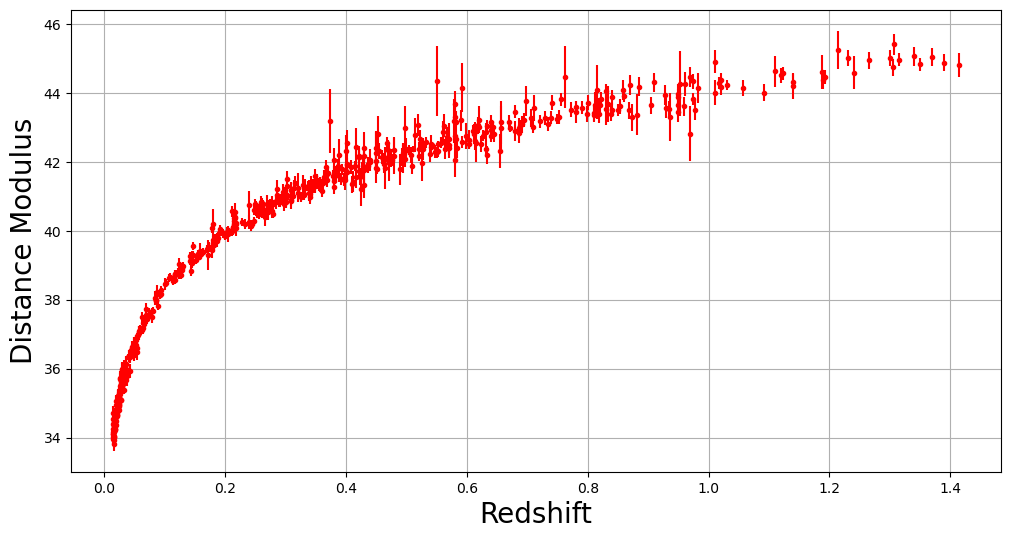

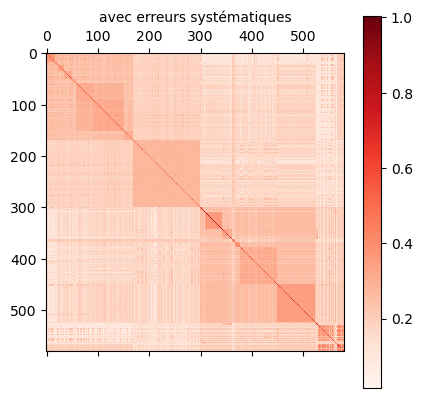

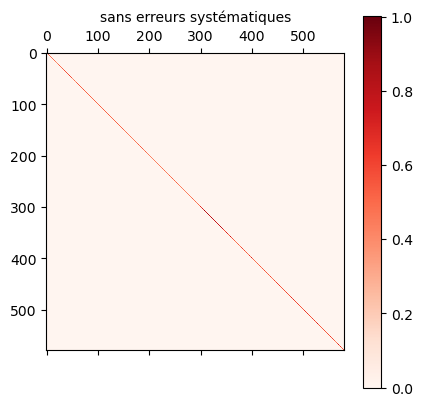

In [24]:
# Lecture du catalogue
# Inversion de la matrice de covariance et stockage des données
sys_covar_matrix = np.loadtxt('SCPUnion2.1_covmat_sys.txt') # sans correction des erreurs systématiques 
inv_covar = np.linalg.inv(sys_covar_matrix) # inverse de la matrice de covariance des erreurs à utiliser pour le chi^2
catalogue = asciitable.read('SCPUnion2.1_mu_vs_z.txt')
zs_data = catalogue['redshift']
distmod_data = catalogue['distance_modulus']

print("Les champs du catalogue sont: \n {}".format(catalogue.keys()))

plt.figure(figsize=(12,6))
plt.errorbar(catalogue['redshift'], catalogue['distance_modulus'], catalogue['distance_mod_err'], fmt='r.')
plt.xlabel('Redshift', fontsize=20)
plt.ylabel('Distance Modulus', fontsize=20)
plt.grid()

# Lecture des fichiers
nosys_covar_matrix = np.loadtxt('SCPUnion2.1_covmat_nosys.txt') 
sys_covar_matrix = np.loadtxt('SCPUnion2.1_covmat_sys.txt') 

# Affichage de la matrice de covariance
plt.set_cmap('Reds')
plt.matshow(np.abs(sys_covar_matrix)**0.2) # **0.2 pour un meilleur contraste
plt.colorbar()
plt.title('avec erreurs systématiques', fontsize=10)

plt.matshow(np.abs(nosys_covar_matrix)**0.2)
plt.colorbar()
plt.title('sans erreurs systématiques', fontsize=10)

### 2. Modèle physique

Module de distance $\mu$ en fonction du décalage vers le rouge $z$ pour un modèle cosmologique plat avec divers $H_0$ et $\Omega_M$, avec les données sur le même graphique.


<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_23535/4214057448.py:12: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(zs, cur_cosmo.distmod(zs), label=f'$\Omega_m$ = {Om:1.2f}')


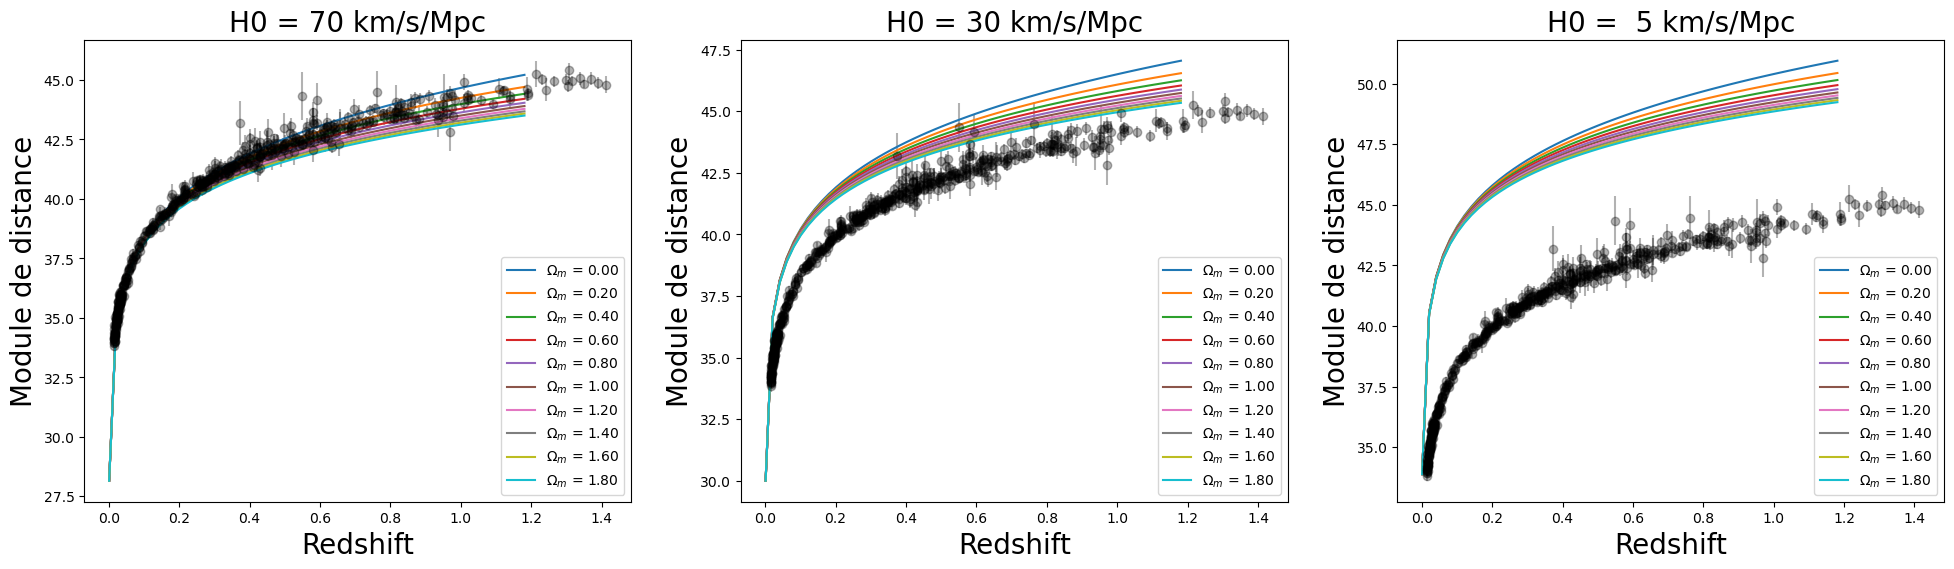

In [25]:
default_H0 = 70.
test_H0 = [default_H0, 30., 5] #km/s/Mpc

plt.figure(figsize=(8*len(test_H0),6))

for i in range(len(test_H0)):
    plt.subplot(1,len(test_H0),i+1)
    plt.errorbar(catalogue['redshift'], catalogue['distance_modulus'], catalogue['distance_mod_err'], fmt='ko', alpha=0.3)
    zs = np.arange(1e-3, 1.2, 0.02)
    for Om in np.arange(0.0, 2.0, 0.2):
        cur_cosmo = cosmology.FlatLambdaCDM(test_H0[i], Om)
        plt.plot(zs, cur_cosmo.distmod(zs), label=f'$\Omega_m$ = {Om:1.2f}')
    plt.legend(loc='lower right')
    plt.title(r'H0 = {0:2.0f} km/s/Mpc'.format(test_H0[i]), fontsize=20)
    plt.xlabel('Redshift', fontsize=20)
    plt.ylabel('Module de distance', fontsize=20)
    #plt.ylim(40,45)
    #plt.xlim(0.4,1.2)


### 3. Modèle de bruit et $\chi^2$

Si une donnée (une supernova décrite par son module de distance $\mu_i$ pour un redshift $z_i$) est supposée issue du modèle $y$ de paramètre $\theta$, avec une erreur additive tirée aléatoirement sur une gaussienne centrée de variance $\sigma^2_i$ (supposée égale à l'incertitude de mesure), alors la densité de probabilité de $\mu_i(z_i)$ pour la $i$ème observation est

$ \displaystyle p(\mu_i; \boldsymbol{\theta}) \propto \exp \left (-\frac{(\mu_i-y(z_i,\boldsymbol{\theta}))^2}{2\sigma^2_i}\right)$.

Cependant les erreurs sont corrélées entre-elles :

$\displaystyle p(\boldsymbol{\mu}; \boldsymbol{\theta}) \propto \exp \left (-\frac{1}{2} (\boldsymbol{\mu}-\boldsymbol{y}(\boldsymbol{\theta}))^\intercal \mathbf{C}^{-1} (\boldsymbol{\mu}-\boldsymbol{y}(\boldsymbol{\theta}))\right)$ 

(dans le cas idéal cas d'erreurs non corrélées, la matrice $\mathbf{C}$ est diagonale, d'éléments $1/\sigma_i^2$.)

Nous pouvons maintenant considèrer $p(\boldsymbol{\mu}; \boldsymbol{\theta})$ non plus comme une fonction du vecteur observation, $\boldsymbol{\mu}$ mais comme une fonction des paramètres $\boldsymbol{\theta}$ du modèle à $\boldsymbol{\mu}$ donné. On appelle cette fonction $\cal{L}(\boldsymbol{\theta}|\boldsymbol{\mu})$, la [*vraisemblance*](http://www.astromatic.net/m2aais/notes/Estimators.html#fonction-de-vraisemblance). Le maximum de cette fonction est atteint lorsque la différence entre modèle et données, pondérée par la covariance des erreur, est minimale. 

Ceci survient lorsque le vecteur paramètres $\boldsymbol{\theta}$ est tel que la fonction $\chi^2(\boldsymbol{\theta})$ atteint sa valeur minimale : 
<br><br>
$ \displaystyle \chi^2_{min} =  \chi^2 (\boldsymbol{\hat \theta}) = (\boldsymbol{\mu}-\boldsymbol{y}(\hat{\boldsymbol{\theta}}))^\intercal \mathbf{C}^{-1} (\boldsymbol{\mu}-\boldsymbol{y}(\boldsymbol{\hat{\theta}}))$.


<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:14: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_23535/1861446988.py:2: SyntaxWarning: invalid escape sequence '\c'
  """ fonction qui calcule le $\chi^2$ pour un modèle cosmologique plat donné ($H_0$, $\Omega_M$) """
/tmp/ipykernel_23535/1861446988.py:13: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('$\Omega_M$', fontsize=20)
/tmp/ipykernel_23535/1861446988.py:14: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$\chi^2$', fontsize=20)


Minimum atteint pour Omega_M proche de  0.286286
Minimum de Chi2 = 545.229383 pour 579 degrés de liberté
Le Chi2 réduit est     0.9417 qui est bien dans l'intervalle [    0.9412 ;     1.0588] : l'ajustement du modèle aux données est tel qu'attendu pour des erreurs gaussiennes de covariance 'inv_covar'.


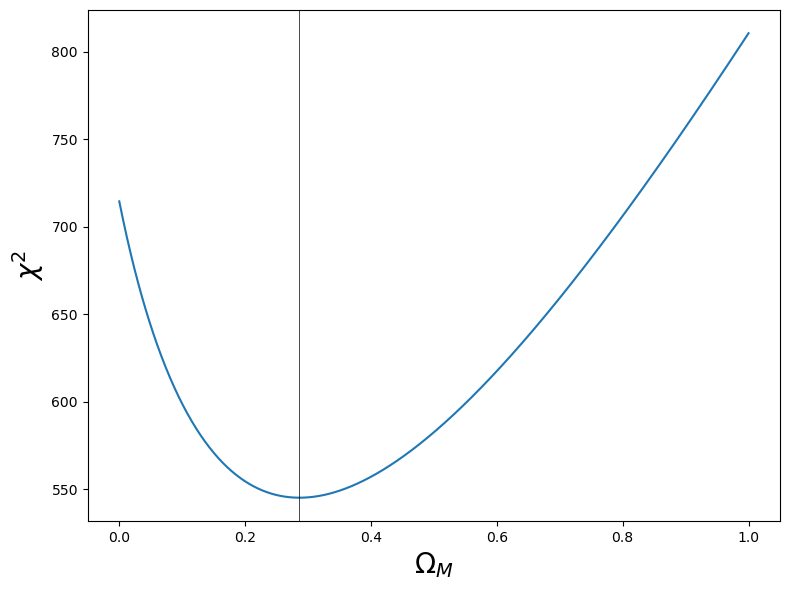

In [26]:
def ChisqLambda_flat(H0 = 70, Om = 1.):
    """ fonction qui calcule le $\chi^2$ pour un modèle cosmologique plat donné ($H_0$, $\Omega_M$) """
    cosmo = cosmology.FlatLambdaCDM(H0, Om)
    predicted_distmod = cosmo.distmod(zs_data).value
    chisq = (predicted_distmod - distmod_data).T @ inv_covar @ (predicted_distmod - distmod_data)
    return chisq

Om_range = np.linspace(0.0, 1.0, 1000)
chisq_Om = [ChisqLambda_flat(Om = curOm) for curOm in Om_range] 

plt.figure(figsize=(8,6))
plt.plot(Om_range, chisq_Om)
plt.xlabel('$\Omega_M$', fontsize=20)
plt.ylabel('$\chi^2$', fontsize=20)
aminchisq = np.argmin(chisq_Om)
minchisq = chisq_Om[aminchisq]
plt.axvline(Om_range[aminchisq],lw=.5,c="k")
plt.tight_layout()


print('Minimum atteint pour Omega_M proche de  %g'%Om_range[aminchisq])

k = len(zs_data) - 1
print('Minimum de Chi2 = %f pour %d degrés de liberté' % (minchisq, k)) 

print(f"Le Chi2 réduit est {minchisq/k:10.4f} qui est bien dans l'intervalle [{1-np.sqrt(2/k):10.4f} ; {1+np.sqrt(2/k):10.4f}] : "\
    "l'ajustement du modèle aux données est tel qu'attendu pour des erreurs gaussiennes de covariance 'inv_covar'.")

# Comme le $\chi^2$ réduit (=$\chi^2$/dof = 545.2 / 579 = 0.94) est ici 
# 1) inférieur à 1 et 
# 2) très voisin de 1 (et plus précisément dans l'intervalle attendu pour un bon modèle $[1-\sqrt{2/k}, 1+\sqrt{2/k}]$ avec ici $k = 579$), 
# nous pouvions nous attendre à cette conclusion : un "bon" modèle doit avoir un $\chi^2$ réduit proche de 1, 
# ce qui veut dire qu'il est en moyenne (quadratique) à une distance de "1 $\sigma$" de chaque point de mesure 
# dans le cas d'erreurs non-correlées, est qu'il est donc statistiquement compatible avec l'ensemble 
# des points de mesure compte-tenu des incertitudes supposées gaussiennes.      



### 4. Vecteur paramètre

Cas où l'on souhaite faire varier plusieurs paramètres à la fois, et étudier les éventuelles dépendances entre eux.

In [27]:
def Chisq_LCDM(H0_Om_Ol):
    """ Chi2 avec comme paramètre une liste des 3 paramètres ($H_0$, $\Omega_M$, $\Omega_\Lambda$) """
    predicted_distmod = cosmology.LambdaCDM(*H0_Om_Ol).distmod(zs_data).value
    chisq = (predicted_distmod - distmod_data).T @ inv_covar @ (predicted_distmod - distmod_data)
    return chisq


<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_23535/190561432.py:2: SyntaxWarning: invalid escape sequence '\O'
  """ Chi2 avec comme paramètre une liste des 3 paramètres ($H_0$, $\Omega_M$, $\Omega_\Lambda$) """


<>:14: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:17: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_23535/2052349345.py:14: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('$\Omega_M$', fontsize=20)
/tmp/ipykernel_23535/2052349345.py:15: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega_\Lambda$', fontsize=20)
/tmp/ipykernel_23535/2052349345.py:17: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Carte du $\chi^2$'+' pour $H_0$={0} km/s/Mpc'.format(H0))


minimum atteint pour : Omega_M = 0.30303, Omega_Lambda = 0.737374 545.212974645489


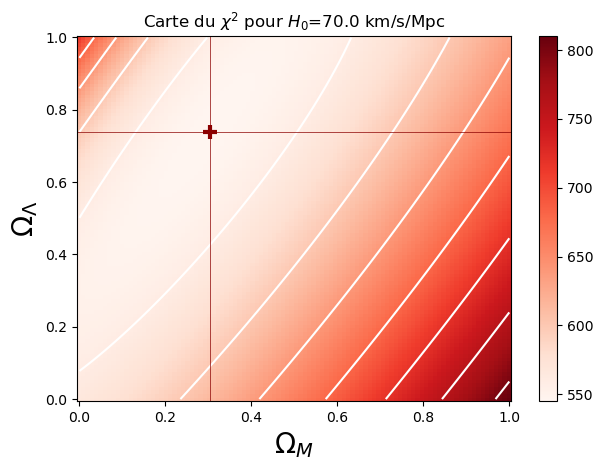

In [28]:
### SUR UNE GRILLE : 

vector_Om = np.linspace(0.,1.,100)
vector_Ol = np.linspace(0.,1.,100)
H0 = 70.

chi2s = np.zeros((len(vector_Om), len(vector_Ol)))
for i_Om, Om in enumerate(vector_Om):
    for i_Ol, Ol in enumerate(vector_Ol):
        chi2s[i_Om, i_Ol] = Chisq_LCDM([H0, Om, Ol])
        
plt.pcolor(vector_Om, vector_Ol, chi2s.T, shading='auto') # Warning : transpose chi2s for the pcolor function...!
plt.colorbar()
plt.xlabel('$\Omega_M$', fontsize=20)
plt.ylabel('$\Omega_\Lambda$', fontsize=20)
plt.contour(vector_Om, vector_Ol, chi2s.T, colors='white')
plt.title('Carte du $\chi^2$'+' pour $H_0$={0} km/s/Mpc'.format(H0))
plt.tight_layout()

minchi2 = np.unravel_index(np.argmin(chi2s),chi2s.shape)
print("minimum atteint pour : Omega_M = %g, Omega_Lambda = %g"%(vector_Om[minchi2[0]],vector_Ol[minchi2[1]]),np.min(chi2s))
plt.plot(vector_Om[minchi2[0]],vector_Ol[minchi2[1]],marker="+",c="darkred",ms="10",mew="3")
plt.axvline(vector_Om[minchi2[0]],c="darkred",lw=.5)
plt.axhline(vector_Ol[minchi2[1]],c="darkred",lw=.5)

### END SOLUTION

### 5. Barres d'erreurs sur les paramètres.

Incertitudes sur les paramètres : $\sigma_{\theta}$. 

On peut utiliser deux méthodes :

- méthode A:
<br>
$\sigma_{\theta}$ obtenu par une approximation gaussienne de la fonction de vraisemblance au pic. L'incertitude est alors donnée par la déviation standard $\sigma_\theta$ de cette gaussienne, qui est aussi telle que $1/\sigma_\theta^2$ est égal (vous pouvez le vérifier par le calcul) à l'opposé de la dérivée seconde de la log-vraissemblance $\ln L = -\frac 12 \chi^2$, ou autrement dit  $\sigma_\theta^2 = \frac{2}{d^2 \chi^2/d\theta^2}$.<br>

- méthode B: <br>
 $\sigma_{\theta}$ obtenu par la région de l'espace des paramètres telle que $\chi^2 < \chi^2_{min} + 1$. 


1.  Univers plat et un seul paramètre $\Omega_M$ et méthode A


In [29]:
amin = np.argmin(chisq_Om)
def deriv2(arr, x, pos):
    # use central derivative
    h = x[pos+1]-x[pos]
    res = arr[pos+1]+arr[pos-1]-2*arr[pos]
    return res/(h*h)

secondderiv = deriv2(chisq_Om, Om_range, amin)
# attention on calcule la derivee seconde du chi2 au pic. La vraisemblance est l'exponentielle de -1/2 chi2. Attention aux signe et au facteur 2.
stdom = 1/np.sqrt(secondderiv/2)
print("La dérivée seconde du chi2 donne une estimation de l'erreur sur l'estimation de Omega_M : %g"%stdom)

La dérivée seconde du chi2 donne une estimation de l'erreur sur l'estimation de Omega_M : 0.0303436


2. Univers plat et un seul paramètre $\Omega_M$  et  méthode B

In [30]:
# L'erreur (région de confiance à 68%) est telle que $\chi^2 < \chi^2_{min} + 1$ car il y a un paramètre (cf cours).
i_Om_acceptable = np.where(chisq_Om <= chisq_Om[amin] + 1)[0]
Om_min_max = [np.min(Om_range[i_Om_acceptable]), np.max(Om_range[i_Om_acceptable])]
print(f"Erreur sur Om d'après le chi^2: {(Om_min_max[1]-Om_min_max[0])/2:1.4f}")

Erreur sur Om d'après le chi^2: 0.0300



3. Univers non plat et $H_0$ fixé : paramètres $\Omega_M$ et $\Omega_\Lambda$, et méthode A.

In [31]:
minchi2 = np.unravel_index(np.argmin(chi2s),chi2s.shape)
i_Om_min = minchi2[0]
i_Ol_min = minchi2[1]

# Utilisée plus tard
lkl_grid = np.exp(-.5*(chi2s-chi2s[minchi2[0],minchi2[1]])) 

secondderiv_Om = deriv2(chi2s[:,i_Ol_min], vector_Om, i_Om_min)
secondderiv_Ol = deriv2(chi2s[i_Om_min,:], vector_Ol, i_Ol_min)

def derivcross(arr, x, y, posx, posy):
    # use central derivative
    hx = x[posx+1]-x[posx-1]
    resx = (arr[posx+1,:]-arr[posx-1,:])/hx
    hy = y[posy+1]-y[posy-1]
    resy = (resx[posy+1]-resx[posy-1])/hy
    return resy

secondderiv_OmOl = derivcross(chi2s, vector_Om, vector_Ol, i_Om_min, i_Ol_min)

print("Incertitude sur les paramètres par la méthode A :")
Sigma_inv = np.array([[secondderiv_Om, secondderiv_OmOl], [secondderiv_OmOl, secondderiv_Ol]])/2
# attention au  facteur 2 due à  la "dérivée seconde" du chi2 donne 2 fois l'inverse courbure de la log-vraisemblance

Sigma = np.linalg.inv(Sigma_inv)
sigma5_3 = Sigma
print("Covariance : ",Sigma)
print("Déviation std (Omega_M) = %g"%np.sqrt(Sigma[0,0]))
print("Déviation std (Omega_Lambda) = %g"%np.sqrt(Sigma[1,1]))

# Les incertitudes sont bien plus élevées que dans le cas d'un univers plat car on explore un modèle plus général.
# La corrélation entre paramètres est importante et contribue notablement à l'incertitude.


Incertitude sur les paramètres par la méthode A :
Covariance :  [[0.01197428 0.01662951]
 [0.01662951 0.02882806]]
Déviation std (Omega_M) = 0.109427
Déviation std (Omega_Lambda) = 0.169788


In [32]:
def p_nsigma(n):
    """ Probabilté d'obtenir un tirage gaussien autour de la moyenne, à +/-  n*sigma_\theta """
    return .5*(scipy.special.erf(n/np.sqrt(2))-scipy.special.erf(-n/np.sqrt(2)))
print(p_nsigma(1),p_nsigma(2),p_nsigma(3))

0.6826894921370859 0.9544997361036416 0.9973002039367398



4. Univers non plat et $H_0$ fixé : paramètres $\Omega_M$ et $\Omega_\Lambda$, et méthode B.

In [33]:
# L'erreur, définie ici comme la région de confiance à 68%, 
# est telle que $\chi^2 < \chi^2_{min} + 2.30$ car il y a deux paramètres.

from scipy.stats import chi2 as chi2_law

print("Incertitude sur les paramètres par la méthode B (chi2 < chi2min + 1): = région de confiance à '1 sigma', contenant 39% des points car on est à 2 dimensions :")
delta_chi2 = 1 

i_Om_acceptable = np.where(chi2s <= np.min(chi2s) + delta_chi2)[0]
i_Ol_acceptable = np.where(chi2s <= np.min(chi2s) + delta_chi2)[1]

Om_min_max_2D = [np.min(vector_Om[i_Om_acceptable]), np.max(vector_Om[i_Om_acceptable])]
print(f"Erreur (1 sigma, ou région 39%) sur Om d'après le chi^2:  {(Om_min_max_2D[1]-Om_min_max_2D[0])/2:10.3f}")
Ol_min_max_2D = [np.min(vector_Ol[i_Ol_acceptable]), np.max(vector_Ol[i_Ol_acceptable])]
print(f"Erreur (1 sigma, ou région 39%) sur Ol d'après le chi^2:  {(Ol_min_max_2D[1]-Ol_min_max_2D[0])/2:10.3f}")


print("Incertitude sur les paramètres par la méthode B (chi2 < chi2min + 2.3) = région de confiance contenant 68% des points:")
delta_chi2 = chi2_law.ppf(0.683, 2)

i_Om_acceptable = np.where(chi2s <= np.min(chi2s) + delta_chi2)[0]
i_Ol_acceptable = np.where(chi2s <= np.min(chi2s) + delta_chi2)[1]

Om_min_max_2D = [np.min(vector_Om[i_Om_acceptable]), np.max(vector_Om[i_Om_acceptable])]
print(f"Erreur (région 68%) sur Om d'après le chi^2:  {(Om_min_max_2D[1]-Om_min_max_2D[0])/2:10.3f}")
Ol_min_max_2D = [np.min(vector_Ol[i_Ol_acceptable]), np.max(vector_Ol[i_Ol_acceptable])]
print(f"Erreur (région 68%) sur Ol d'après le chi^2:  {(Ol_min_max_2D[1]-Ol_min_max_2D[0])/2:10.3f}")



Incertitude sur les paramètres par la méthode B (chi2 < chi2min + 1): = région de confiance à '1 sigma', contenant 39% des points car on est à 2 dimensions :
Erreur (1 sigma, ou région 39%) sur Om d'après le chi^2:       0.106
Erreur (1 sigma, ou région 39%) sur Ol d'après le chi^2:       0.167
Incertitude sur les paramètres par la méthode B (chi2 < chi2min + 2.3) = région de confiance contenant 68% des points:
Erreur (région 68%) sur Om d'après le chi^2:       0.162
Erreur (région 68%) sur Ol d'après le chi^2:       0.253



Dans le premier cas, on retrouve aux erreurs numériques près l'incertitude mesurée par la courbure de la fonction de vraisemblance. Dans le second cas, on a défini arbitrairement une région de confiance à 68%, qui correspond à une limite $\chi^2$ = $\chi^2_{min}+2.3$. Mais ce nombre 68% est très arbitraire surtout à deux dimensions comme ici. Pour retrouver la barre d'erreur de la première méthode, il faut utiliser comme attendu (cf TP 4) une région de confiance à 39%, ou de façon équivalente, une limite $\chi^2$ = $\chi^2_{min}+1$ (cf premier cas).

### 6. Recherche automatique du maximum de vraisemblance

On peut aussi utiliser des algorithmes disponibles dans scipy : 

In [34]:
from scipy.optimize import minimize
params_init = [75.,0.2,0.7]
res = minimize(Chisq_LCDM, params_init, method='nelder-mead', options={'disp': True})
print("paramètres [H0, Om, Ol] = {0}".format(res.x))
print("chi2 min = {0}".format(Chisq_LCDM(res.x)))
print("dof = {0}".format(len(zs_data)))
res_NM = res

Optimization terminated successfully.
         Current function value: 545.109167
         Iterations: 84
         Function evaluations: 146
paramètres [H0, Om, Ol] = [69.66195847  0.29131343  0.6964039 ]
chi2 min = 545.1091666284068
dof = 580


Utilisation de la méthode Levenberg-Marquardt :

In [35]:
def Chi_LCDM_vec_eig(H0_Om_Ol):
    predicted_distmod = cosmology.LambdaCDM(*H0_Om_Ol).distmod(zs_data).value
    v = np.dot(mat.T,(predicted_distmod - distmod_data))/diag**.5
    return v

def Chi_LCDM_vec_eig_2(H0_Om_Ol):
    return Chi_LCDM_vec_eig((70,H0_Om_Ol[0],H0_Om_Ol[1]))

# Levenberg-Marquart : on doit réaliser une SVD pour sphériser les vecteurs données
diag,mat = np.linalg.eig(sys_covar_matrix)

# 3 paramètres
res = scipy.optimize.least_squares(Chi_LCDM_vec_eig, res_NM.x,method="lm")
H = np.dot(res.jac.T,res.jac)
invH = np.linalg.inv(H)

# 2 paramètres
res = scipy.optimize.least_squares(Chi_LCDM_vec_eig_2, res_NM.x[1:],method="lm")
print("Cas non-diagonal, LM, H0=70")
print("Paramètres [Om, Ol] = {0}".format(res.x))
print("chi2 min = {0}".format(Chisq_LCDM((70,res.x[0],res.x[1]))))
print("dof = {0}".format(len(zs_data)-2)) # 2 paramètres

H = np.dot(res.jac.T,res.jac)
invH2 = np.linalg.inv(H)
print("Covariance : ",invH2)
print("Déviation std (Omega_M) = %g"%np.sqrt(invH2[0,0]))
print("Déviation std (Omega_Lambda) = %g"%np.sqrt(invH2[1,1]))

print("Pour rappel, résultat de la question 5.2")
print("Déviation std (Omega_M) = %g"%np.sqrt(Sigma[0,0]))
print("Déviation std (Omega_Lambda) = %g"%np.sqrt(Sigma[1,1]))


Cas non-diagonal, LM, H0=70
Paramètres [Om, Ol] = [0.30047928 0.73620177]
chi2 min = 545.2114388735446
dof = 578
Covariance :  [[0.01190638 0.01659454]
 [0.01659454 0.02886241]]
Déviation std (Omega_M) = 0.109116
Déviation std (Omega_Lambda) = 0.169889
Pour rappel, résultat de la question 5.2
Déviation std (Omega_M) = 0.109427
Déviation std (Omega_Lambda) = 0.169788


## 7. Méthode Monte-Carlo


Les méthodes de recherche de minimum permettent de trouver rapidement la solution de maximum de vraisemblance, mais ne sont pas très précises pour évaluer les erreurs lorsque les corrélations sont fortes et la vraisemblance fortement non-gaussienne (en temps que fonction du vecteur paramètre).

Comme nous l'avons vu plus-haut, les grilles permettent d'évaluer finement la fonction de vraisemblance mais sont vite limitées en grande dimension.<br>
En particulier, sans connaissance a priori de la solution la construction d'une évaluation sur grille passera beaucoup de son temps dans des régions de faible probabilité.

Dans le TP précédent, nous avons tracé des histogrammes 1D ou 2D de coupes à travers la fonction de vraisemblance (ou de façon équivalente dans notre cas, le $\chi^2$). Ces coupes impliquent le choix et la connaissance des autres paramètres. On parle alors de "conditionnelles".

Il est souvent plus intéressant de tracer des histogrammes en intégrant les variations possibles des autres paramètres. On parle alors de marginales.

De même, nous avons cherché les paramètres maximisant la vraisemblance, mais on peut aussi, très justement, se poser la question de la valeur moyenne de ces paramètres et de leur covariance.

Dans l'approche bayésienne, toutes ces quantités (histogrammes, moyennes, variances, etc) s'expriment simplement comme des intégrales de fonctions sous la distribution postérieure des paramètres. 

### Rappels de cours

Par exemple, la moyenne de $\theta_i$, le $i$ème élément du vecteur de paramètres $\boldsymbol{\theta}$,  s'écrit simplement

$ \displaystyle \int \theta_i p(\boldsymbol{\theta}|\boldsymbol{\mu}) d^k\theta,$

où $k$ est la dimension du vecteur $\boldsymbol{\theta}$ (nombre de paramètres du modèle), tandis que la valeur dans le $j$ème intervalle de l'histogramme unidimensionnel pour le $i$ème paramètre, marginalisé sur les autres sera

$ \displaystyle \int_{\theta_i\in\mathrm{intervalle}_j} p(\boldsymbol{\theta}|\boldsymbol{\mu}) d^k\theta.$

De telles intégrales peuvent être évaluées sur des grilles, mais il existe une méthode bien plus efficace pour cela, l'intégration Monte-Carlo. En effet, n'importe quelle intégrale sous une probabilité $p$ donnée peut s'approcher par un tirage aléatoire,

$ \displaystyle \int f(\boldsymbol{\theta}) p(\boldsymbol{\theta}|\boldsymbol{\mu}) d^k\theta \approx \frac{1}{N}\sum_{n=1}^{N}f(\boldsymbol{\theta}_n),$ 

où les $\boldsymbol{\theta}_n$ sont N tirages indépendants sous la distribution $p(\boldsymbol{\theta}|\boldsymbol{\mu})$.

On sent bien qu'une telle approche sera plus efficace en grande dimension qu'une grille.
En tirant les points sous la distribution postérieure des paramètres, on choisit préférentiellement des régions de l'espace des paramètres de haute probabilité, améliorant ainsi la précision de l'intégrale dans les régions qui contribuent fortement.

Reste donc à savoir comment tirer sous la distribution des paramètres postérieure à l'obtention des observations.
On rappelle que, dans le contexte bayésien, la vraisemblance est écrite comme la distribution de probabilité des données conditionnelle à un modèle $p(\boldsymbol{\mu}|\boldsymbol{\theta})$, et non comme la distribution des paramètres conditionnelle aux données $\cal{L}(\boldsymbol{\theta}|\boldsymbol{\mu})$.
Le [théorème de Bayes](http://www.astromatic.net/m2aais/notes/Inference.html#theoreme-de-bayes) nous explique comment obtenir la distribution postérieure, à condition de disposer d'une distribution a priori des paramètres.
Cet a priori est important.
Il peut influer significativement sur le résultat final s'il est très informatif.
C'est d'ailleurs en utilisant comme a priori le résultat de mesures précédentes que l'on peut combiner facilement des contraintes provenant de différentes expériences.
Il est important de s'assurer que l'a priori choisi n'ajoute pas d'informations "trompeuses" au problème.


Il faut maintenant être capable de réaliser un tirage sous cette distribution postérieure.
Cela sera le but de la suite de ce TP.
On pourrait pour cela calculer la postérieure via le théorème de Bayes, l'intégrer, l'inverser pour corriger un tirage uniforme multidimensionnel.
Cette approche est extrêmement coûteuse et n'est pas utilisable dans la plupart des cas.
Nous allons donc explorer un algorithme efficace, très largement employé dans le domaine.

### Metropolis-Hasting Markov Chain Monte-Carlo

La méthode [Markov Chain Monte Carlo (MCMC)](https://fr.wikipedia.org/wiki/Méthode_de_Monte-Carlo_par_chaînes_de_Markov) est un algorithme qui propose de construire un tirage approché sous une loi postérieure, à partir d'une [chaîne markovienne](https://fr.wikipedia.org/wiki/Cha%C3%AEne_de_Markov) de tirage dans l'espace des paramètres.
Une condition d'acceptance/rejet permet à cette [marche aléatoire](https://fr.wikipedia.org/wiki/Marche_al%C3%A9atoire) de converger vers la bonne distribution. 

Il existe plusieurs façons de construire un tel algorithme, en particulier [l'échantillonage de Gibbs](https://fr.wikipedia.org/wiki/Échantillonnage_de_Gibbs), l'algorithme [Hamiltonian Monte Carlo](https://en.wikipedia.org/wiki/Hamiltonian_Monte_Carlo) et le plus répandu que nous allons étudier ici, la méthode de [Metropolis-Hastings](https://fr.wikipedia.org/wiki/Algorithme_de_Metropolis-Hastings).

Dans sa version la plus simple, celle-ci propose de réaliser la marche aléatoire sous la forme d'une nouvelle position (dans l'espace des paramètres) candidate
$\boldsymbol{\theta}'_{i+1} = \boldsymbol{\theta}_i + \boldsymbol{\Delta\theta}$, avec $\boldsymbol{\Delta\theta}$ un vecteur aléatoire tiré sous une distribution gaussienne bien choisie pour accélérer la convergence.
La condition d'acceptance est donnée par $\boldsymbol{\theta}_{i+1} = \boldsymbol{\theta}'_{i+1}$ (on accepte la position candidate) avec la probabilité

$ \displaystyle \alpha = \frac{\pi(\boldsymbol{\theta}'_{i+1})}{\pi(\boldsymbol{\theta}_{i})}$,

avec  $\pi(\boldsymbol{\theta}_i) = p(\boldsymbol{\mu}|\boldsymbol{\theta}_i) p(\boldsymbol{\theta}_i)$, où $p(\boldsymbol{\mu}|\boldsymbol{\theta})$ est la vraisemblance calculée au point de l'espace des paramètres $\boldsymbol{\theta}$ et $p(\boldsymbol{\theta})$ la distribution a priori. 

En pratique, on peut réaliser à chaque itération un tirage uniforme sur $[0,1]$ : si le tirage est inférieur à $\alpha$, alors la position candidate ($\boldsymbol{\theta}_{i+1} = \boldsymbol{\theta}_i + \boldsymbol{\Delta\theta}$) est acceptée, sinon elle est rejetée ($\boldsymbol{\theta}_{i+1} = \boldsymbol{\theta}_i$).

Nous avons ici sauté de nombreuses étapes de la dérivation pour donner le résultat final. On  notera simplement qu'une des forces de cet algorithme est de ne nécessiter que des calculs de la vraisemblance (et de l'a priori), sans devoir auparavant calculer la normalisation de la distribution a posteriori.


### Moteur MCMC

### 🏋 Exercices 
1. Éditer et compléter la fonction `mcmc_step()` ci-dessous afin d'implémenter le tirage du nouveau point proposé et son test d'acceptation par l'algorithme de Metropolis-Hastings

In [43]:
def mcmc_step(chi2_func, xi, SigmaProp, extra=(), chi2_courant=None):
    """
    chi2_func calcule le chi2 de sorte que la fonction de vraisemblance soit exp(-.5*chi2)
    xi est le point actuel dans l'espace des paramètres
    SigmaProp est la matrice de covariance utilisée pour proposer un nouveau point
    """

    if chi2_courant==None:
        chi2_courant = chi2_func(xi, *extra) # calculer la vraisemblance initiale si nécessaire
    # Mon code :
    step = np.random.multivariate_normal(np.zeros(len(xi)),SigmaProp)
    xf = np.add(xi,step)
    # Fin mon code
    try:
        chi2_1 = chi2_func(xf, *extra)
    except:
        # refuser proprement le point s'il est en dehors du domaine
        # de validité des paramètres
        return False, chi2_courant, xi
    
    #### --------------------------------------
    #### Exercice : vérifier l'acceptance ici !
    alpha = np.exp(-.5*chi2_1)/np.exp(-.5*chi2_courant) #Prior = uniforme
    accept = (np.random.random()<alpha)
    #### --------------------------------------

    if accept:    # on teste l'acceptance
        return True, chi2_1, xf # on accepte
    return False, chi2_courant, xi # on refuse : on reste sur les valeurs acutelles.


Dans la suite nous utiliserons la fonction du module `tp2.py` : `tp2.mcmc(mcmc_step, chi2_func, xi, SigmaProp, nstep)` pour réaliser des chaînes (marches aléatoires).

`mcmc_step()` est la fonction que nous venons de définir, `chi2_func` est une fonction calculant un $\chi^2$ (c'est-à-dire $-2  \times \log\;$ vraisemblance), `xi` une position initiale, `SigmaProp` la covariance de la marche aléatoire gaussienne, et `nstep` le nombre de pas.  

Cette fonction renvoie `tp2.chain`, une classe contenant une chaîne de points. On utilisera les méthodes `tp2.chain.mean()` et `tp2.chain.covariance()` pour obtenir les moyennes et covariances de la chaîne.

Dans un premier temps nous allons vérifier que la fonction `mcmc_step()` est correctement implémentée en lançant des cas de tests bien choisis :

2. Lire attentivement, exectuer et comprendre la cellule suivante et vérifier que l'on sait correctement explorer une gaussienne bidimensionnelle:


test : step = [-0.94044705 -2.59602892]
test : step = [0.99196049 3.49154769]
test : step = [2.50885419 3.1408443 ]
test : step = [2.20469184 4.32134467]
test : step = [-2.92183095 -6.58122359]
test : step = [-0.1438387   2.83020576]
test : step = [0.67650332 1.35379845]
test : step = [-1.81290547 -3.56827627]
test : step = [-0.06720081  4.47564605]
test : step = [-0.03336563  0.9206236 ]
test : step = [-0.42072716 -2.86445167]
test : step = [-1.59400686 -1.01127808]
test : step = [-1.55880647 -0.02085101]
test : step = [2.5896595  4.92999731]
test : step = [0.90704094 2.45131237]
test : step = [1.54656844 5.39797802]
test : step = [-0.71950857 -1.74703287]
test : step = [2.00222623 6.16740822]
test : step = [-1.25883391 -0.97463669]
test : step = [-0.00150812  0.32049713]
test : step = [-0.98802654  1.64541333]
test : step = [1.52048755 3.95246026]
test : step = [-1.80567573  2.79762404]
test : step = [2.82550364 4.32216283]
test : step = [3.1526423  3.68691331]
test : step = [ 0.1469

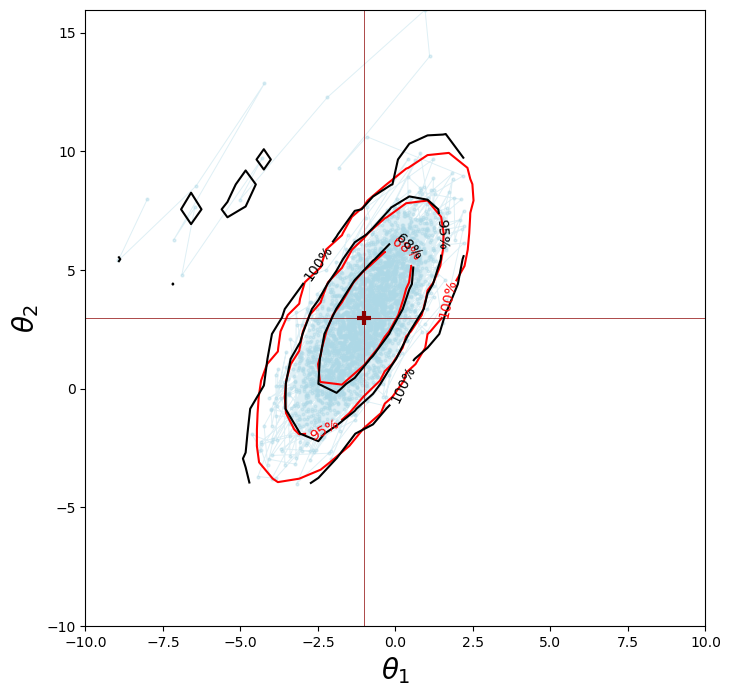

In [37]:
import tp2

# créons un chi2 correspondant à une gaussienne de moyenne 1,-3
# et de variance donnée par sigtest
moy = [-1,3]
sigtest = np.array([[1,1.5],[1.5,4]])
gauss_test = tp2.make_chi2_gauss(moy,sigtest)

# pour vérification, calculons la vraisemblance sur une grille
p0 = np.linspace(-10,10,30)
p1 = np.linspace(-10,10,30)
gauss_grid = tp2.gridme(p0,p1,gauss_test,chi2=True)

# Explorons maintenant la postérieure avec un MCMC
# On se place loin pour vérifier la convergence, on peut partir de là où l'on veut.
start_point = [-8,8]
# Le choix optimal pour la proposition dans le cas gaussien est sigma*2.38**2/ndim
sigma_prop = sigtest * (2.38**2)*1./2

gauss_chain = tp2.mcmc(mcmc_step,gauss_test,start_point,sigma_prop,nstep=10000)

# On vérifie l'acceptance (le taux de propositions acceptées au cours de la chainz) qui doit être entre 44% (1D) et 24% (dimension infinie)
# ~35% est attendu pour 2D
print("Acceptance",gauss_chain.acceptance())

# On vérifie la moyenne et la variance (on doit retrouver les valeurs ci-dessus)
print("Moyenne",gauss_chain.mean())
print("Covariance\n",gauss_chain.covariance())

# On affiche une densité 2D pour la grille
plt.figure(figsize=(8,8))
plt.xlabel('$\\theta_1$', fontsize=20)
plt.ylabel('$\\theta_2$', fontsize=20)
tp2.pretty_contour(p0, p1, gauss_grid.T, tp2.get_level, (p_nsigma(1),p_nsigma(2),p_nsigma(3)), colors="red",)
plt.plot((-1,),(3,),marker="+",c="darkred",ms="10",mew="3")
plt.axvline((-1,),c="darkred",lw=.5)
plt.axhline((3,),c="darkred",lw=.5)
# Maintenant, pour la chaîne, nous laissons l'algorithme déterminer sur quel intervalle
# travailler et l'on demande 20 subdivisions dans chaque direction
pp0,pp1,gauss_chain_grid = gauss_chain.regrid2d(0,1,20,20) 

tp2.pretty_contour(pp0,pp1,gauss_chain_grid.T,tp2.get_level,(p_nsigma(1),p_nsigma(2),p_nsigma(3)),colors="black")

# FACULTATIF, on affiche le "mouvement brownien"
gauss_chain.plot_brown(0,1)


Nous avons exploré la vraisemblance sans fournir de distribution a priori, contrairement à ce qu'exige le théorème de Bayes.
En fait, cela revient à supposer un a priori uniforme et de support infini, ce qui n'est pas mathématiquement correct et pose des problèmes de normalisation.

Il existe toutes sortes de façons de déterminer une distribution a priori;
soit parce que le modèle physique nous donne des informations sur la distribution des paramètres (par exemple région de l'espace des paramètres qui n'ont pas de sens physique), soit encore parce que l'a posteriori d'une expérience précédente nous donne une information sur la distribution a priori des paramètres.

Ici, nous allons d'abord ajouter un a priori simple sous la forme d'une distribution uniforme.
Suivant le théorème de Bayes, il suffit de multiplier la vraisemblance par la distribution a priori et d'explorer le résutat.
C'est ce que nous allons faire dans la suite, en supposant arbitrairement que le modèle physique sous-jacent interdit les valeurs plus grandes que 1 pour le premier paramètre, et non-comprises entre -5 et 5 pour le second.

3. Ecrire une fonction, dont les arguments sont `pmin` et `pmax`, qui définit la fonction $-\frac{1}{2}\log\ U(\mathrm{pmin},\mathrm{pmax})$ (à une constante arbitraire près), c'est-à-dire moins le demi-logarithme de la distribution uniforme entre `pmin` et `pmax` (tous deux des vecteurs).
En dehors de l'intervalle $[\mathrm{min},\mathrm{max}]$ le log de la distribution n'est évidemment pas défini, la fonction ainsi définie devra alors lever l'erreur `tp2.UndefinedChi2` que la fonction `mcmc_step()` sait gérer.
Choisir les valeurs des vecteurs `pmin` et `pmax` correspondantes au cas décrit au dessus.

4. Ecrire une fonction qui combine l'a priori et une vraisemblance, pour donner l'a posteriori (en raisonnant de préférence sur les log-vraisemblances). Appliquez la au cas de vraisemblance gaussienne de la question 2 ci-dessus et à l'a priori uniforme ci-dessus.

5. Explorer avec un MCMC en s'inspirant de la question 2 ci-dessus, discuter l'acceptance, la moyenne et la variance, afficher une densité 2D.

test : step = [-1.79448574 -4.10280918]
test : step = [-2.02943321 -1.03757785]
test : step = [1.07783021 0.40244522]
test : step = [-0.65807708  0.60532978]
test : step = [ 0.36883162 -4.21755446]
test : step = [-1.84474205 -5.90545548]
test : step = [4.47773025 3.60510057]
test : step = [0.38340164 3.2806684 ]
test : step = [-0.64903895 -1.25888592]
test : step = [1.48409706 6.90907858]
test : step = [-1.09282046 -1.21530655]
test : step = [-2.69610685 -7.85294752]
test : step = [0.57521504 0.42387762]
test : step = [0.72862693 2.16353001]
test : step = [3.99553385 5.17181808]
test : step = [ 0.37838596 -1.73176789]
test : step = [-0.08977446 -0.61868233]
test : step = [ 1.02354954 -2.72945846]
test : step = [2.31491893 6.4299186 ]
test : step = [-0.17096039 -1.77453508]
test : step = [-1.94766342 -1.11606822]
test : step = [-0.2858279   1.84152506]
test : step = [-0.60235503 -1.83410877]
test : step = [-0.0413925   2.00762058]
test : step = [-2.9589563  -6.03882474]
test : step = [-

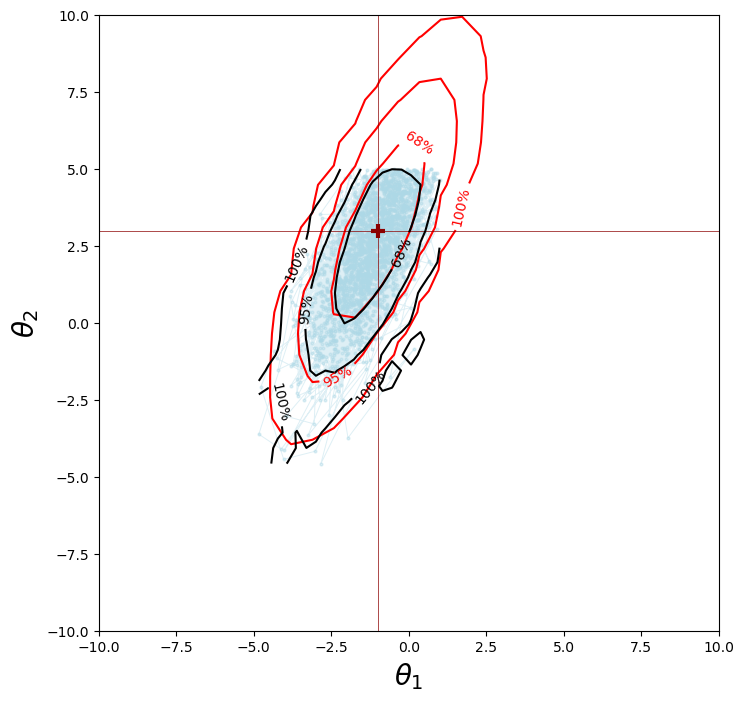

In [ ]:
### BEGIN SOLUTION

# Question 7.3
def logunif(pmin,pmax):
    def f(p) :
        for i in range(len(pmax)):
            if p[i]>pmax[i] or p[i]<pmin[i] : raise tp2.UndefinedChi2
        area = np.prod([pmax[i] - pmin[i] for i in range(len(pmax))])
        return(-.5*np.log(1/area))
    return(f)

logPrior = logunif([-100,-5],[1,5])
# Question 7.4
# Comme on travaille avec des "$\chi^2$" (en vérité -.5 log vraisemblance)
# le produit des distributions est donné par la somme des $\chi^2$.
# On résoud le problème une fois pour toutes en écrivant une fonction qui somme 
# une liste arbitraire de $\chi^2$, ce qui nous permettra de construire
# des a priori plus complexes ou de combiner des résultats d'expériences.
def combine_chi2(chi2_list):
    def f(x):
        res = 0
        for i in range(len(chi2_list)):
            res += float(chi2_list[i](x))
        return(res)
    return(f)

sumChi2 = combine_chi2([logPrior,gauss_test])
        
"""
Renvoie une fonction qui est la somme 
des fonctions de log-vraisemblance fournies dans la liste chi2_list
"""
    # A COMPLETER
     
# Question 7.5


sigtest = np.array([[1,1.5],[1.5,4]])

# pour vérification, calculons la vraisemblance sur une grille
p0 = np.linspace(-10,10,30)
p1 = np.linspace(-10,10,30)
gauss_grid = tp2.gridme(p0,p1,gauss_test,chi2=True)

# Explorons maintenant la postérieure avec un MCMC
# On se place loin pour vérifier la convergence, on peut partir de là où l'on veut.
start_point = [0,0]
# Le choix optimal pour la proposition dans le cas gaussien est sigma*2.38**2/ndim
sigma_prop = sigtest * (2.38**2)*1./2

gaussWPrior_chain = tp2.mcmc(mcmc_step,sumChi2,start_point,sigma_prop,nstep=10000)

# On vérifie l'acceptance (le taux de propositions acceptées au cours de la chainz) qui doit être entre 44% (1D) et 24% (dimension infinie)
# ~35% est attendu pour 2D
print("Acceptance",gaussWPrior_chain.acceptance())

# On vérifie la moyenne et la variance (on doit retrouver les valeurs ci-dessus)
print("Moyenne",gaussWPrior_chain.mean())
print("Covariance\n",gaussWPrior_chain.covariance())

# On affiche une densité 2D pour la grille
plt.figure(figsize=(8,8))
plt.xlabel('$\\theta_1$', fontsize=20)
plt.ylabel('$\\theta_2$', fontsize=20)
tp2.pretty_contour(p0, p1, gauss_grid.T, tp2.get_level, (p_nsigma(1),p_nsigma(2),p_nsigma(3)), colors="red",)
plt.plot((-1,),(3,),marker="+",c="darkred",ms="10",mew="3")
plt.axvline((-1,),c="darkred",lw=.5)
plt.axhline((3,),c="darkred",lw=.5)
# Maintenant, pour la chaîne, nous laissons l'algorithme déterminer sur quel intervalle
# travailler et l'on demande 20 subdivisions dans chaque direction
pp0,pp1,gaussWP_chain_grid = gaussWPrior_chain.regrid2d(0,1,20,20) 

tp2.pretty_contour(pp0,pp1,gaussWP_chain_grid.T,tp2.get_level,(p_nsigma(1),p_nsigma(2),p_nsigma(3)),colors="black")

# FACULTATIF, on affiche le "mouvement brownien"
gaussWPrior_chain.plot_brown(0,1)


## 8. Cas cosmologique simple

Nous allons maintenant reproduire les résultats cosmologiques avec la méthode MCMC appliquée aux données de supernovae.

Dans un premier temps, reproduisons les résultats des question 4.4 (minimum de chi2 sur une grille 2D), 5.5 et 5.8 (régions à 68% de confiance)

1. Utiliser la routine `tp2.mcmc()` pour explorer la vraisemblance définie par le $\chi^2$ de la question 4.2.
On imposera que les deux paramètres soient inclus entre 0 et 1.
Pour choisir la covariance de la marche aléatoire, on utilisera la matrice Sigma mesurée sur la log-vraisemblance à la question 5.3 multipliée par le facteur `(2.38**2)*1./2` qui permet d'élargir la covariance de façon optimale pour le MCMC.
Explorer au moins 10000 points.
Afficher l'acceptance, la moyenne et la variance.
Calculer les barres d'erreurs pour les deux paramètres et comparer à 5.3.
Comparer la densité 2D avec celle obtenue avec une grille (Figure 4.2). 

Acceptance 0.34136586341365865
Moyenne [0.28818959 0.70904758]
Covariance
 [[0.00989251 0.01304928]
 [0.01304928 0.02294434]]


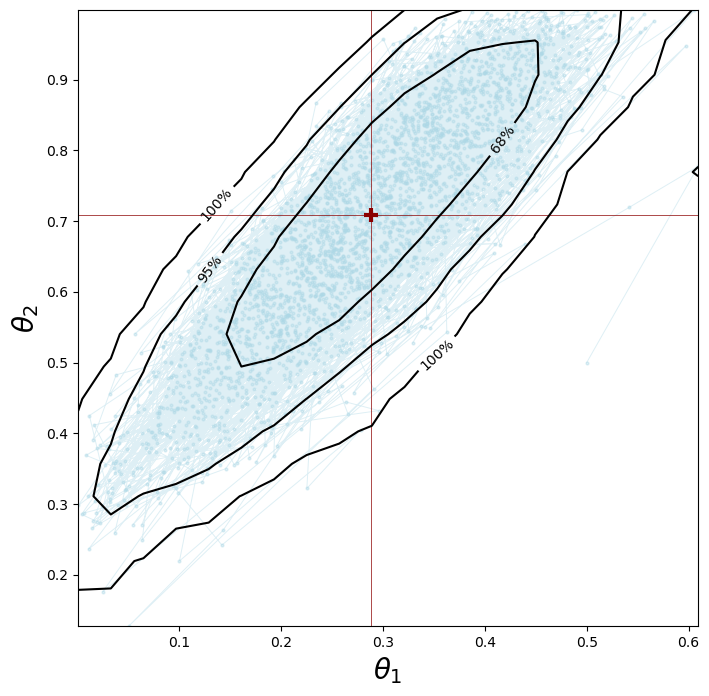

In [44]:
### BEGIN SOLUTION
def chi2cdm(l):
    [Om,Ol] = l
    return(Chisq_LCDM([H0, Om, Ol]))



sigtest = sigma5_3
p0 = np.linspace(0,1,30)
p1 = np.linspace(0,1,30)
gauss_grid = tp2.gridme(p0,p1,gauss_test,chi2=True)
start_point = [0.5,0.5]
sigma_prop = sigtest * (2.38**2)*1./2
gaussWPrior_chain = tp2.mcmc(mcmc_step,combine_chi2([chi2cdm,logunif([0,0],[1,1])]),start_point,sigma_prop,nstep=10000)

# On vérifie l'acceptance (le taux de propositions acceptées au cours de la chainz) qui doit être entre 44% (1D) et 24% (dimension infinie)
# ~35% est attendu pour 2D
print("Acceptance",gaussWPrior_chain.acceptance())

# On vérifie la moyenne et la variance (on doit retrouver les valeurs ci-dessus)
print("Moyenne",gaussWPrior_chain.mean())
print("Covariance\n",gaussWPrior_chain.covariance())

# On affiche une densité 2D pour la grille
plt.figure(figsize=(8,8))
plt.xlabel('$\\theta_1$', fontsize=20)
plt.ylabel('$\\theta_2$', fontsize=20)
#tp2.pretty_contour(p0, p1, gauss_grid.T, tp2.get_level, (p_nsigma(1),p_nsigma(2),p_nsigma(3)), colors="red",)
plt.plot((gaussWPrior_chain.mean()[0],),(gaussWPrior_chain.mean()[1],),marker="+",c="darkred",ms="10",mew="3")
plt.axvline((gaussWPrior_chain.mean()[0],),c="darkred",lw=.5)
plt.axhline((gaussWPrior_chain.mean()[1],),c="darkred",lw=.5)
# Maintenant, pour la chaîne, nous laissons l'algorithme déterminer sur quel intervalle
# travailler et l'on demande 20 subdivisions dans chaque direction
pp0,pp1,gaussWP_chain_grid = gaussWPrior_chain.regrid2d(0,1,20,20) 

tp2.pretty_contour(pp0,pp1,gaussWP_chain_grid.T,tp2.get_level,(p_nsigma(1),p_nsigma(2),p_nsigma(3)),colors="black")

# FACULTATIF, on affiche le "mouvement brownien"
gaussWPrior_chain.plot_brown(0,1)

Nous allons maintenant explorer conjointement H0, $\Omega_M$ et $\Omega_\Lambda$.

2. Explorer la vraisemblance définie par le $\chi^2$ de la section 6 (avec les 3 paramètres).
Choisir un a priori, sachant que $H_0>0$ et $\Omega_M >0$. 
Choisir une matrice de covariance pour la proposition basée sur `invH` de la question 6.
Comment faudrait-il s'assurer de la convergence ?
Calculer les acceptances, moyennes, variances, barres d'erreurs.
Afficher les densités 2D pour toutes les paires de paramètres.
Comparer avec les incertitudes de la section 6.

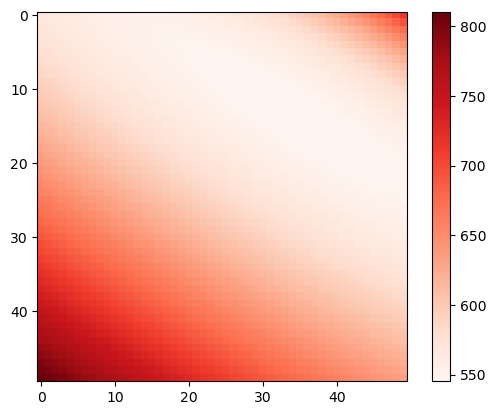

In [67]:
def logChiLCDM(arg):
    return(-0.5*np.log(Chisq_LCDM(arg)))

image = [[Chisq_LCDM([70,a,b]) for b in np.linspace(0,1,50)] for a in np.linspace(0,1,50)]
plt.imshow(image)
plt.colorbar()
plt.show()

/usr/lib/python3/dist-packages/astropy/cosmology/flrw/lambdacdm.py:269: RuntimeWarning: invalid value encountered in arcsin
  return np.arcsin(np.sqrt((y1 - y2) / ((z + 1.0) * Om0 / abs(Ok0) + y1)))


Acceptance 0.2390760923907609
Moyenne [69.61491668  0.27951343  0.66375814]
Covariance
 [[1.18987927 0.03410851 0.14345277]
 [0.03410851 0.01294052 0.02078953]
 [0.14345277 0.02078953 0.04662738]]


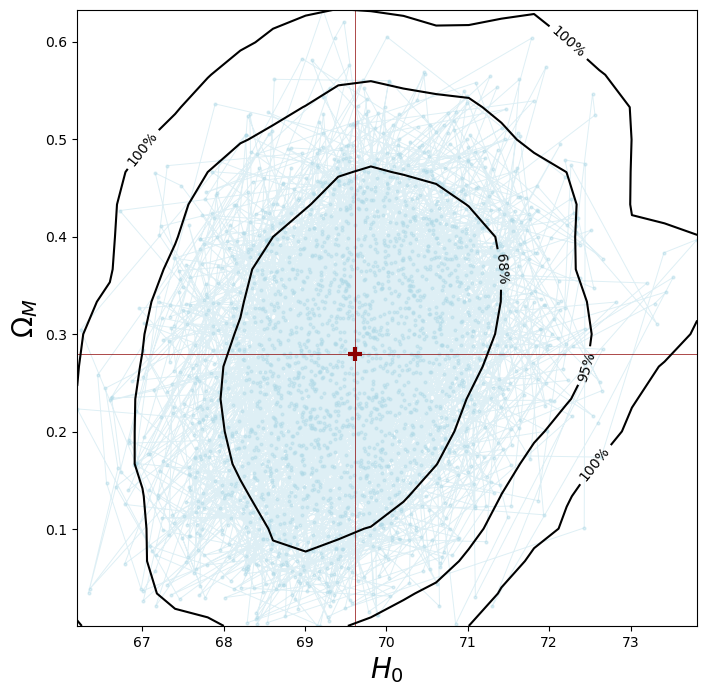

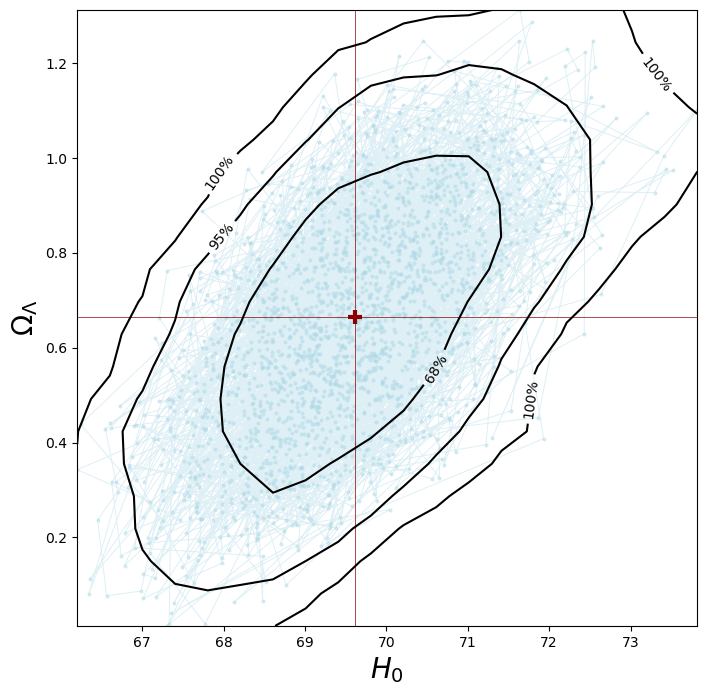

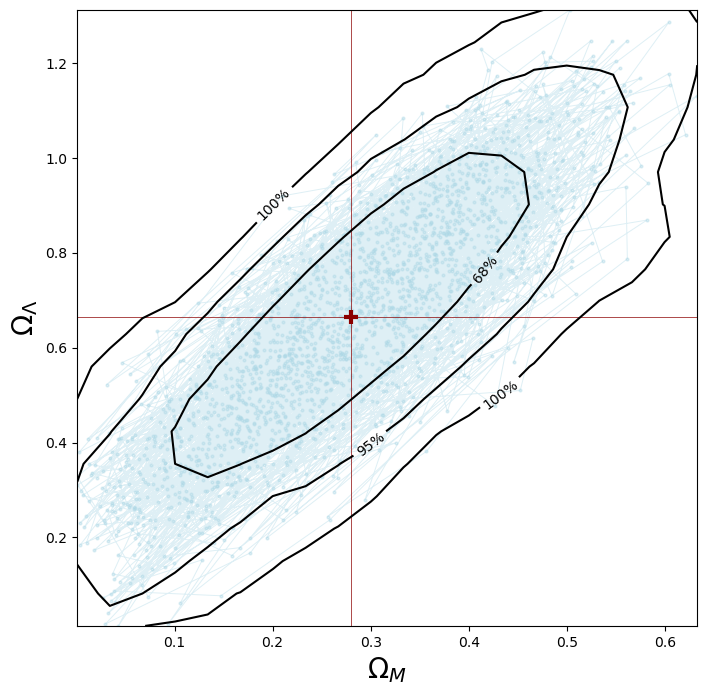

In [73]:
### BEGIN SOLUTION



sigtest = invH
start_point = [70,0.3,0.7]
sigma_prop = sigtest * (2.38**2)*1./2
def logChiLCDM(arg):
    return(-0.5*np.log(Chisq_LCDM(arg)))


gaussWPrior_chain = tp2.mcmc(mcmc_step,combine_chi2([Chisq_LCDM,logunif([0,0,-10],[1E10,1E10,1E10])]),start_point,sigma_prop,nstep=10000)

# On vérifie l'acceptance (le taux de propositions acceptées au cours de la chainz) qui doit être entre 44% (1D) et 24% (dimension infinie)
# ~35% est attendu pour 2D
print("Acceptance",gaussWPrior_chain.acceptance())

# On vérifie la moyenne et la variance (on doit retrouver les valeurs ci-dessus)
print("Moyenne",gaussWPrior_chain.mean())
print("Covariance\n",gaussWPrior_chain.covariance())

# On affiche une densité 2D pour la grille
pairs = [[0,1],[0,2],[1,2]]
names = ['$H_0$','$\\Omega_M$','$\\Omega_\\Lambda$']
for pair in pairs :
    plt.figure(figsize=(8,8))
    plt.xlabel(names[pair[0]], fontsize=20)
    plt.ylabel(names[pair[1]], fontsize=20)
    plt.plot((gaussWPrior_chain.mean()[pair[0]],),(gaussWPrior_chain.mean()[pair[1]],),marker="+",c="darkred",ms="10",mew="3")
    plt.axvline((gaussWPrior_chain.mean()[pair[0]],),c="darkred",lw=.5)
    plt.axhline((gaussWPrior_chain.mean()[pair[1]],),c="darkred",lw=.5)
    pp0,pp1,gaussWP_chain_grid = gaussWPrior_chain.regrid2d(pair[0],pair[1],20,20) 
    tp2.pretty_contour(pp0,pp1,gaussWP_chain_grid.T,tp2.get_level,(p_nsigma(1),p_nsigma(2),p_nsigma(3)),colors="black")
    gaussWPrior_chain.plot_brown(pair[0],pair[1])
    plt.show()




## 9. Préparation de l'évaluation : cas avec énergie noire dynamique

Nous allons maintenant explorer un cas plus complexe dans lequel l'énergie noire, dont l'amplitude aujourd'hui est paramétrée par $\Omega_\Lambda$, n'est plus statique mais peut évoluer au cours du temps.
Cette évolution est décrite par le paramètre d'équation d'état $w$ qui lie la densité et la pression de la composante $w=\frac{P}{\rho}$.
Lorsque ce paramètre vaut -1, l'énergie sombre se comporte comme la constante cosmologique, une force répulsive.
Différents modèles proposent que le champ responsable de l'accélération de l'expansion puisse évoluer et voir son équation d'état varier au cours du temps.
Sauf extension de la physique, cette évolution ne permet pas d'aller vers des valeurs plus petites que -1, et $w$ doit être négatif pour tenir le rôle d'une force répulsive.
Les expériences futures ([Euclid](https://en.wikipedia.org/wiki/Euclid_(spacecraft)), [DESI](https://en.wikipedia.org/wiki/Dark_Energy_Spectroscopic_Instrument)), chercheront à évaluer l'évolution de ce paramètre d'état au cours du temps. Ici, nous évaluerons simplement la possibilité qu'en moyenne ce paramètre diffère de -1, ce qui est déjà très ambitieux avec nos données !

### 🏋 Exercices
1. Écrire une fonction qui calcule le "$\chi^2$" pour quatre paramètres $\Omega_M$ $\Omega_\Lambda$, $H_0$ et $w$.
On utilisera pour cela la classe `wCDM` du module `astropy.cosmology`.
2. Choisir un a priori pour une exploration avec un MCMC.
3. Explorer les 4 paramètres.
Régler correctement l'acceptance. Afficher les moyennes et variances, ainsi que les différentes densités 2D.
Commenter sur la gaussianité des postérieures des paramètres.

In [ ]:
### BEGIN SOLUTION
def Chisq_LCDM(H0_Om_Ol):
    """ Chi2 avec comme paramètre une liste des 3 paramètres ($H_0$, $\Omega_M$, $\Omega_\Lambda$) """
    predicted_distmod = cosmology.wCDM(*H0_Om_Ol).distmod(zs_data).value
    chisq = (predicted_distmod - distmod_data).T @ inv_covar @ (predicted_distmod - distmod_data)
    return chisq



## 10. Evaluation

Nous allons désormais incorporer des informations complémentaires en utilisant les données du rayonnement de fond cosmologique de Planck.
Nous devrions en principe combiner la vraisemblance des données de Planck avec celle que nous venons de construire; mais nous allons ici simplifier le problème en supposant que, pour ce qui nous intéresse, ces contraintes forment des a priori gaussiens sur nos différents paramètres, avec $\Omega_M = 0.3100 \pm 0.0063$, $H_0 = 67.86 \pm 0.65$ et $\Omega_\Lambda = 0.6893 \pm 0.0058$.

1. Implémenter un a priori avec ces valeurs. 
2. Refaire les figures de densité 2D de la chaîne précédente `ch_w` et y superposer les contours à 1, 2 et 3$\sigma$ pour ces a priori seuls (i.e. obtenus avec une chaine MCMC utilisant uniquement les a priori, sans vraisemblance).
3. Explorer la vraisemblance des données des supernovae avec cet a priori (c'est à dire l'a posteriori).
Comment régler la covariance ?
Vérifier l'acceptance.
4. Calculer les moyennes, variances et conclure sur la valeur de $w$ dans ce modèle.
5. Pour chaque couple de paramètres, afficher sur la même figure les densités de probabilité de l'a posteriori calculées soit avec soit sans l'a priori.